### KNN( K-Nearest Neighbors )

- "가까운 이웃의 다수결"로 분류하는 모델
- KNeigborsClassifier , n_neighbors(K)를 사용
- 새 데이터가 들어오면 가장 가까운 K개 이웃을 찾아서 다수결로 분류 

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris = load_iris()

In [3]:
X , y = iris.data , iris.target
X_tr , X_te , y_tr , y_te = train_test_split(
    X , y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    stratify = y ) # 품종 비율을 train/test 데이터에 거의 일정하게 유지 

In [4]:
# (A) 스케일링 없이 

knn_raw = KNeighborsClassifier(n_neighbors=5) 
# 새로운 데이터가 들어왔을때, 가장 가까운 이웃 데이터 5개를 보고 다수결로 품종 예측 
knn_raw.fit(X_tr,y_tr)
acc_raw = accuracy_score(y_te,knn_raw.predict(X_te))

In [5]:
acc_raw

1.0

In [16]:
# 스케일링

scaler = StandardScaler()

scaled_train = scaler.fit_transform(X_tr)
scaled_test = scaler.transform(X_te) 

In [17]:
# (B) 스케일링 적용 후 

scaled_knn = KNeighborsClassifier(n_neighbors=5)
scaled_knn.fit(scaled_train,y_tr)
ma = scaled_knn.predict(scaled_test)

acc_scaled = accuracy_score(y_te,ma)
print(f"스케일링 적용 후 : {acc_scaled:.3f}")

스케일링 적용 후 : 0.933


### 최적의 K(이웃 수)찾기 

- K가 너무 작으면 예민 = 과대적합 ( Overfitting ) 발생 가능성이 높아지므로 적절한 K를 찾는것이 중요

In [8]:
# k값을 1부터 20까지 하나씩 테스트 
ks = range(1,21)


# k별로 정확도를 저장할 리스트
acc = []

# 가장 좋은 K와 정확도를 저장할 변수
best_k = 0
best_acc = 0

# K값을 하나씩 대입하면서 

for i in ks : 
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(scaled_train,y_tr)
    y_pred = knn.predict(scaled_test)
    acc_scaled = accuracy_score(y_te,y_pred)
    acc.append(acc_scaled)

    if acc_scaled > best_acc :
        best_acc = acc_scaled
        best_k = i

# best_k
best_acc

0.9666666666666667

K값 시각화 

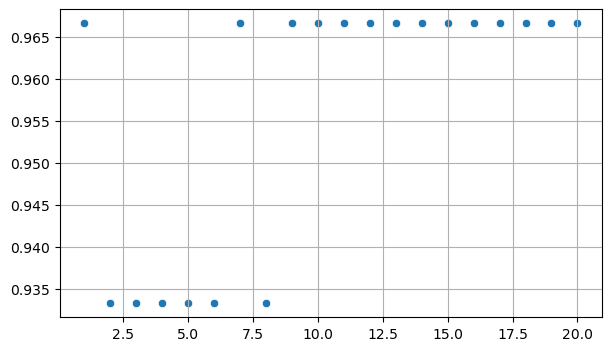

In [9]:
plt.figure(figsize=(7,4))

# plt.plot(ks,acc,"o--")

# plt.asvline(
#     best_k,
#     linestyle = "--",
#     label = "최적 K")

sns.scatterplot(x=ks,y=acc)
plt.grid()
plt.show()

In [10]:
y_te

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [14]:
u_sepal_length = float(input("꽃받침의 길이 : "))
u_sepal_width = float(input("꽃받침의 너비 : "))
u_petal_length = float(input("꽃잎의 길이 : "))
u_petal_width = float(input("꽃잎의 너비 : "))

User_data = pd.DataFrame(
    [[u_sepal_length,u_sepal_width,u_petal_length,u_petal_width]],
    columns = iris.feature_names
)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(scaled_train,y_tr)
u_pred = knn_best.predict(User_data)
result = iris.target_names[u_pred[0]]
# acc_user = accuracy_score(y_te,u_pred)  크기가 안맞아서 실패

print(f"예측된 품종은 {result} 입니다")
print(f"정확도 : {acc[best_k-1]}") # k는 1부터 진입점  -1 필요  

꽃받침의 길이 :  4.4
꽃받침의 너비 :  3.3
꽃잎의 길이 :  2.2
꽃잎의 너비 :  1.1


예측된 품종은 virginica 입니다
정확도 : 0.9666666666666667


C:\Users\cyj\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
u_pred

In [ ]:
result